In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                       TRAINING  CELL                            ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import random
import collections
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

# ── Config ────────────────────────────────────────────────────────────────────
learning_rate  = 0.0002
gamma          = 0.98
buffer_limit   = 6000
rollout_len    = 10
batch_size     = 4
c              = 1.0
TOTAL_EPISODES = 4000
SAVE_INTERVAL  = 1000   # FINAL_PATH 덮어쓰기 주기

FINAL_PATH = 'lunar_lander_ac_final.pt'
BEST_PATH  = 'lunar_lander_ac_best.pt'
LOG_DIR    = f'runs/lunar_lander_ac_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'CUDA   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Log dir: {LOG_DIR}')

# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer():
    def __init__(self):
        self.buffer = collections.deque(maxlen=buffer_limit)

    def put(self, seq_data):
        self.buffer.append(seq_data)

    def sample(self, on_policy=False):
        mini_batch = [self.buffer[-1]] if on_policy else random.sample(self.buffer, batch_size)
        s_lst, a_lst, r_lst, prob_lst, done_lst, is_first_lst = [], [], [], [], [], []
        for seq in mini_batch:
            is_first = True
            for s, a, r, prob, done in seq:
                s_lst.append(s);        a_lst.append([a])
                r_lst.append(r);        prob_lst.append(prob)
                done_lst.append(0.0 if done else 1.0)
                is_first_lst.append(is_first)
                is_first = False
        s    = torch.tensor(s_lst,    dtype=torch.float).to(device)
        a    = torch.tensor(a_lst).to(device)
        prob = torch.tensor(prob_lst, dtype=torch.float).to(device)
        return s, a, r_lst, prob, done_lst, is_first_lst

    def size(self):
        return len(self.buffer)

# ── Actor-Critic Model ────────────────────────────────────────────────────────
# LunarLander-v2: state 8-dim, action 4 discrete
class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1   = nn.Linear(8,   256)
        self.fc2   = nn.Linear(256, 256)
        self.fc_pi = nn.Linear(256, 4)
        self.fc_q  = nn.Linear(256, 4)

    def _trunk(self, x):
        return F.relu(self.fc2(F.relu(self.fc1(x))))

    def pi(self, x, softmax_dim=0):
        return F.softmax(self.fc_pi(self._trunk(x)), dim=softmax_dim)

    def q(self, x):
        return self.fc_q(self._trunk(x))

# ── Train Step ────────────────────────────────────────────────────────────────
def train(model, optimizer, memory, on_policy=False):
    s, a, r, prob, done_mask, is_first = memory.sample(on_policy)

    q    = model.q(s)
    q_a  = q.gather(1, a)
    pi   = model.pi(s, softmax_dim=1)
    pi_a = pi.gather(1, a)
    v    = (q * pi).sum(1).unsqueeze(1).detach()

    rho              = pi.detach() / prob.clamp(min=1e-8)
    rho_a            = rho.gather(1, a)
    rho_bar          = rho_a.clamp(max=c)
    correction_coeff = (1 - c / rho.clamp(min=1e-8)).clamp(min=0)

    q_ret = v[-1] * done_mask[-1]
    q_ret_lst = []
    for i in reversed(range(len(r))):
        q_ret = r[i] + gamma * q_ret
        q_ret_lst.append(q_ret.item())
        q_ret = rho_bar[i] * (q_ret - q_a[i]) + v[i]
        if is_first[i] and i != 0:
            q_ret = v[i-1] * done_mask[i-1]

    q_ret_lst.reverse()
    q_ret    = torch.tensor(q_ret_lst, dtype=torch.float).unsqueeze(1).to(device)
    log_pi_a = torch.log(pi_a.clamp(min=1e-8))
    log_pi   = torch.log(pi.clamp(min=1e-8))
    loss1    = -rho_bar * log_pi_a * (q_ret - v)
    loss2    = -correction_coeff * pi.detach() * log_pi * (q.detach() - v)
    loss     = loss1 + loss2.sum(1) + F.smooth_l1_loss(q_a, q_ret)

    optimizer.zero_grad()
    loss.mean().backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
    optimizer.step()

# ── Main Training Loop ────────────────────────────────────────────────────────
def main():
    env = gym.make('LunarLander-v2')
    memory    = ReplayBuffer()
    model     = ActorCritic().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    score      = 0.0
    best_score = float('-inf')
    writer     = SummaryWriter(log_dir=LOG_DIR)
    print_interval = 20

    print(f'\n{"="*55}')
    print(f'  Training start  |  0 → {TOTAL_EPISODES} episodes')
    print(f'  Buffer warmup   |  training begins after 500 sequences')
    print(f'{"="*55}')

    for n_epi in range(TOTAL_EPISODES):
        s, _     = env.reset()
        done     = False
        ep_score = 0.0

        while not done:
            seq_data = []
            for _ in range(rollout_len):
                prob = model.pi(torch.from_numpy(s).float().to(device))
                a    = Categorical(prob).sample().item()
                s_prime, r, done, truncated, _ = env.step(a)
                done = done or truncated
                seq_data.append((s, a, r / 100.0, prob.detach().cpu().numpy(), done))
                score    += r
                ep_score += r
                s = s_prime
                if done:
                    break

            memory.put(seq_data)
            if memory.size() > 500:
                train(model, optimizer, memory, on_policy=True)
                train(model, optimizer, memory)

        if memory.size() <= 500:
            print(f'  [warmup] epi {n_epi:4d} | buffer: {memory.size():4d}/500 | score: {ep_score:7.1f}')

        writer.add_scalar('Reward/episode', ep_score, n_epi)

        # ── Best model ────────────────────────────────────────────────────────
        if ep_score > best_score:
            best_score = ep_score
            torch.save(model.state_dict(), BEST_PATH)
            print(f'  [best] episode {n_epi} | reward {best_score:.1f} -> {BEST_PATH}')
            writer.add_scalar('Reward/best', best_score, n_epi)

        if n_epi % print_interval == 0 and n_epi != 0:
            avg = score / print_interval
            print(f'# of episode: {n_epi:5d} | avg score: {avg:8.1f} | buffer: {memory.size()}')
            writer.add_scalar('Reward/avg_20ep', avg, n_epi)
            score = 0.0

        # ── Periodic save (overwrite every SAVE_INTERVAL episodes) ────────────
        if n_epi % SAVE_INTERVAL == 0 and n_epi != 0:
            torch.save(model.state_dict(), FINAL_PATH)
            print(f'  [saved] episode {n_epi} -> {FINAL_PATH}')

    env.close()
    writer.close()
    torch.save(model.state_dict(), FINAL_PATH)
    print(f'\nTraining done.')
    print(f'  Final model -> {FINAL_PATH}')
    print(f'  Best  model -> {BEST_PATH}  (best reward: {best_score:.1f})')
    print(f'  TensorBoard: tensorboard --logdir {LOG_DIR}')

main()

Device : cuda
CUDA   : True
GPU    : NVIDIA GeForce RTX 4090
Log dir: runs/lunar_lander_ac_20260517_003001

  Training start  |  0 → 4000 episodes
  Buffer warmup   |  training begins after 500 sequences
  [warmup] epi    0 | buffer:   10/500 | score:  -118.2
  [best] episode 0 | reward -118.2 -> lunar_lander_ac_best.pt
  [warmup] epi    1 | buffer:   17/500 | score:  -134.4
  [warmup] epi    2 | buffer:   25/500 | score:  -129.8
  [warmup] epi    3 | buffer:   34/500 | score:  -227.3
  [warmup] epi    4 | buffer:   42/500 | score:  -183.2
  [warmup] epi    5 | buffer:   49/500 | score:   -64.9
  [best] episode 5 | reward -64.9 -> lunar_lander_ac_best.pt
  [warmup] epi    6 | buffer:   56/500 | score:  -119.4
  [warmup] epi    7 | buffer:   62/500 | score:  -111.9
  [warmup] epi    8 | buffer:   70/500 | score:  -430.5
  [warmup] epi    9 | buffer:   81/500 | score:  -268.4
  [warmup] epi   10 | buffer:   94/500 | score:  -391.5
  [warmup] epi   11 | buffer:  102/500 | score:  -222.1
 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9536\4142926932.py:56: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  s    = torch.tensor(s_lst,    dtype=torch.float).to(device)


# of episode:    60 | avg score:   -173.1 | buffer: 565
# of episode:    80 | avg score:   -259.8 | buffer: 764
# of episode:   100 | avg score:   -269.7 | buffer: 986
# of episode:   120 | avg score:   -192.4 | buffer: 1223
# of episode:   140 | avg score:   -123.7 | buffer: 1492
# of episode:   160 | avg score:   -106.9 | buffer: 1828
# of episode:   180 | avg score:    -47.4 | buffer: 2532
  [best] episode 192 | reward 60.0 -> lunar_lander_ac_best.pt
  [best] episode 193 | reward 77.0 -> lunar_lander_ac_best.pt
  [best] episode 199 | reward 120.4 -> lunar_lander_ac_best.pt
# of episode:   200 | avg score:    -13.9 | buffer: 3884
  [best] episode 213 | reward 191.7 -> lunar_lander_ac_best.pt
# of episode:   220 | avg score:     42.1 | buffer: 5574
  [best] episode 235 | reward 197.4 -> lunar_lander_ac_best.pt
# of episode:   240 | avg score:     68.6 | buffer: 6000
  [best] episode 245 | reward 207.5 -> lunar_lander_ac_best.pt
  [best] episode 251 | reward 263.4 -> lunar_lander_ac_be

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_9536\1714100591.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_

[final] model loaded from lunar_lander_ac_final.pt
Running 5 episodes...

Episode  1/5 | reward:    123.9 | steps: 1000


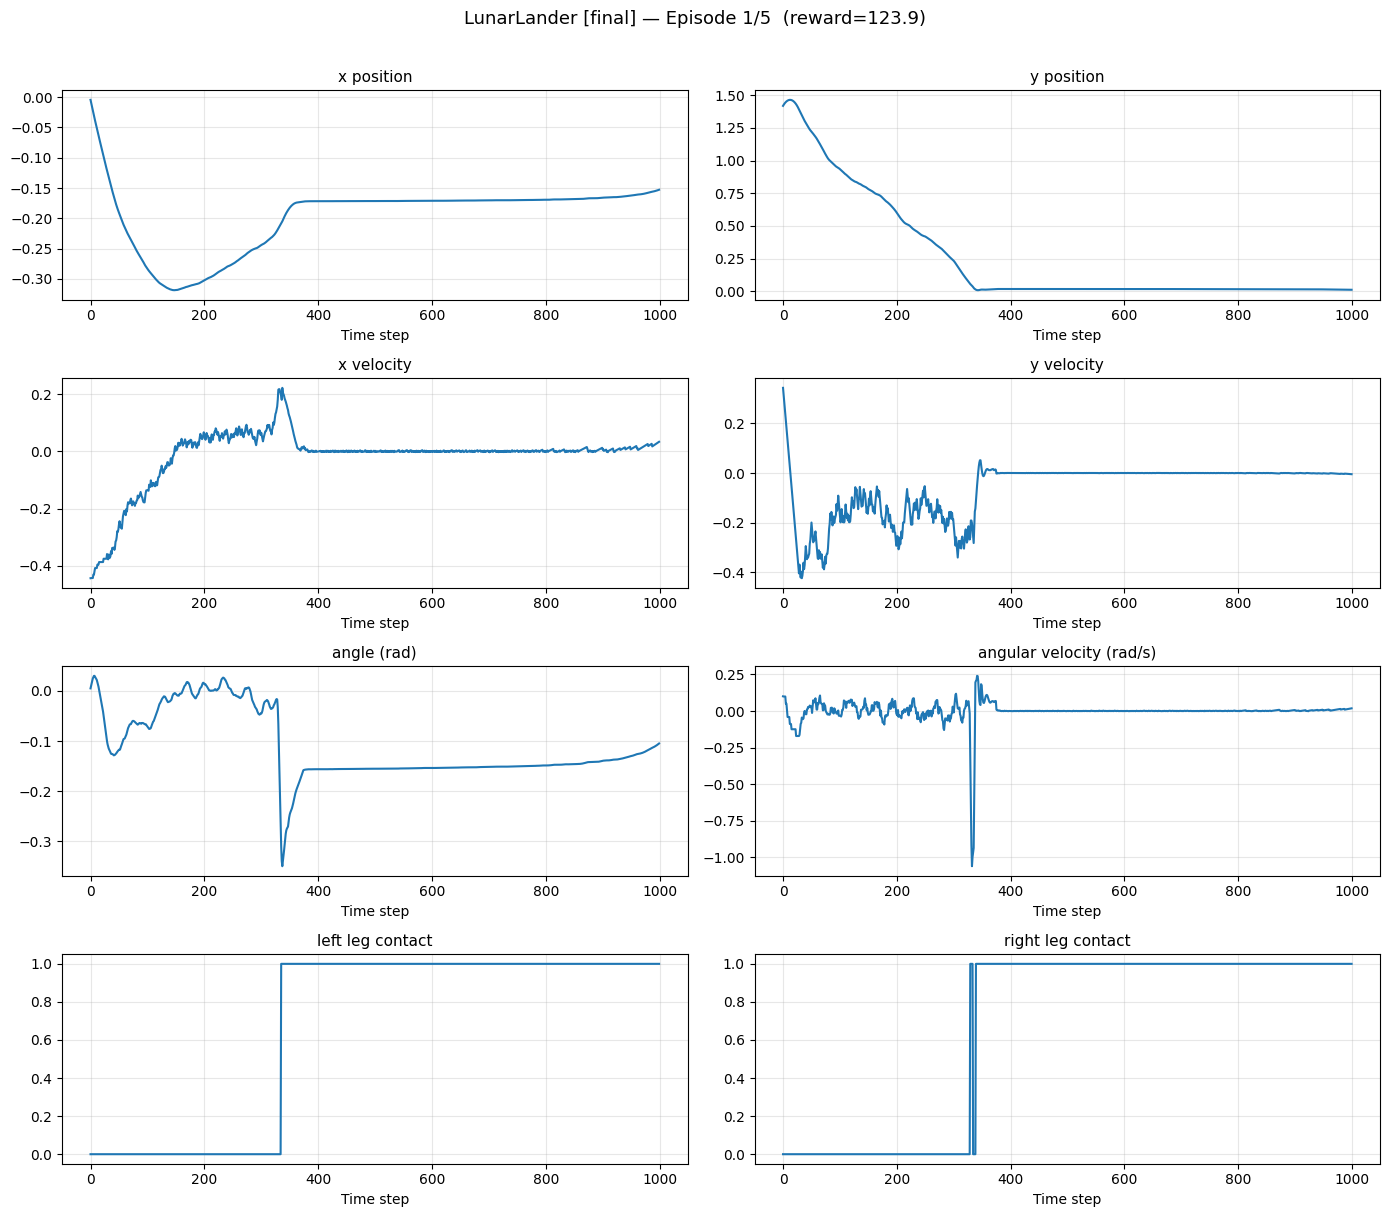

  Plot saved -> lunar_lander_final_ep1.png

Episode  2/5 | reward:    225.0 | steps: 224


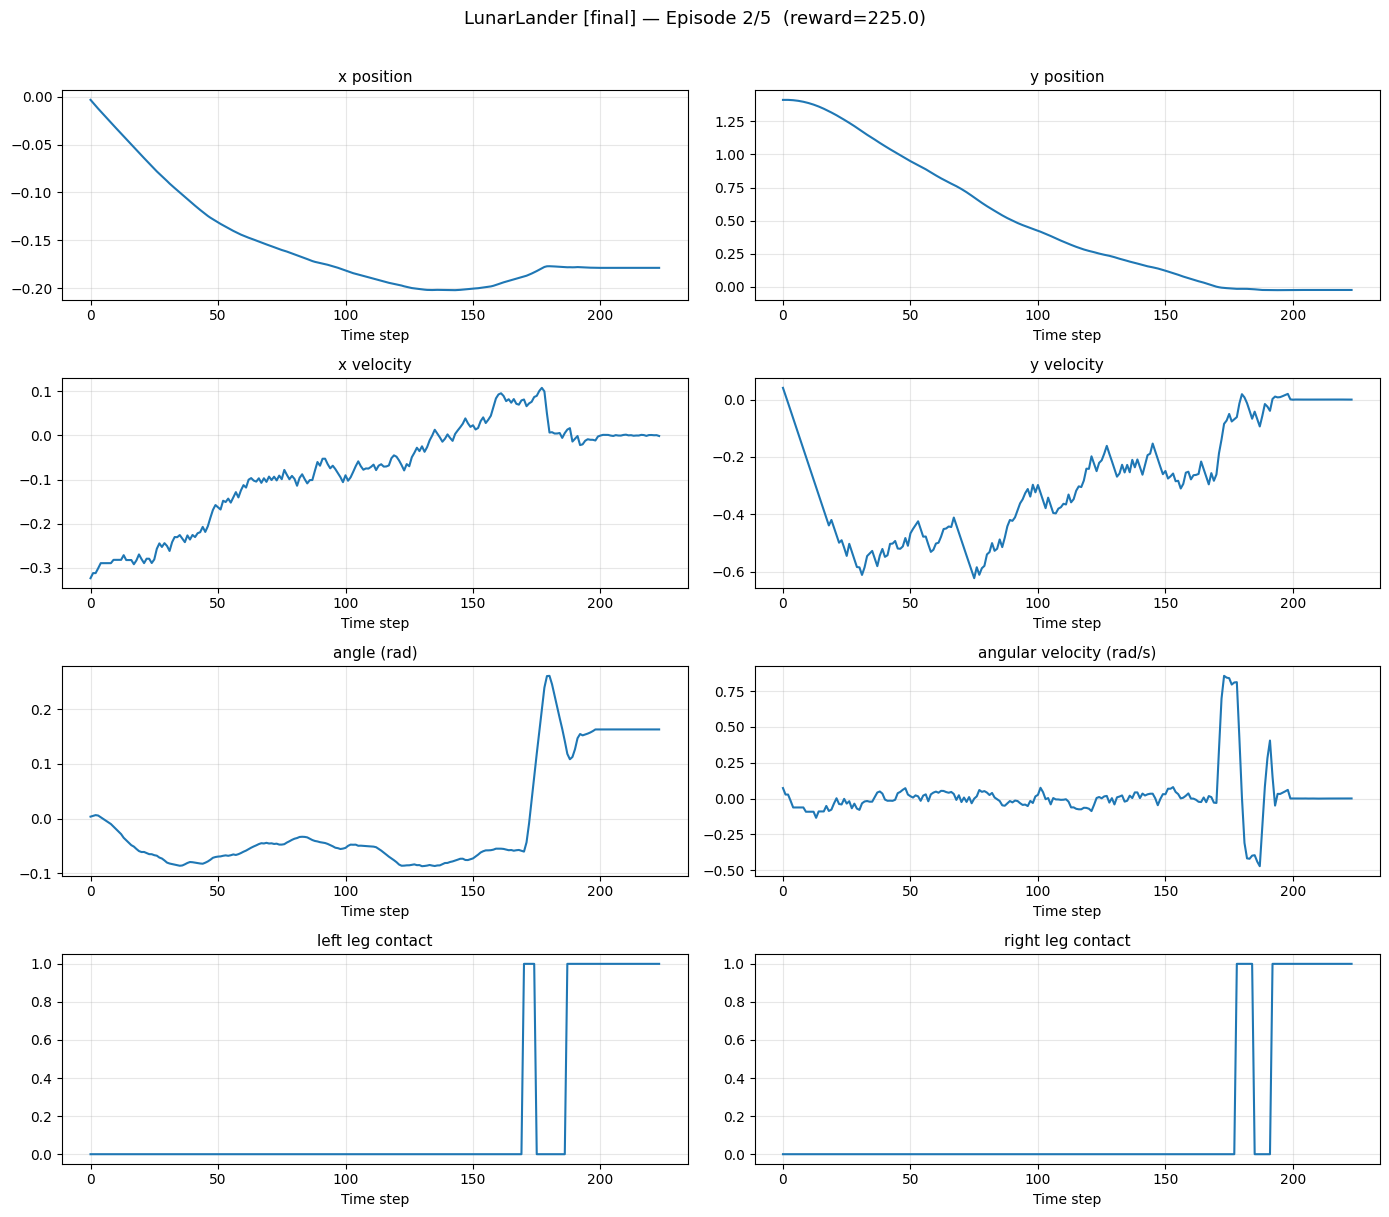

  Plot saved -> lunar_lander_final_ep2.png

Episode  3/5 | reward:    258.8 | steps: 247


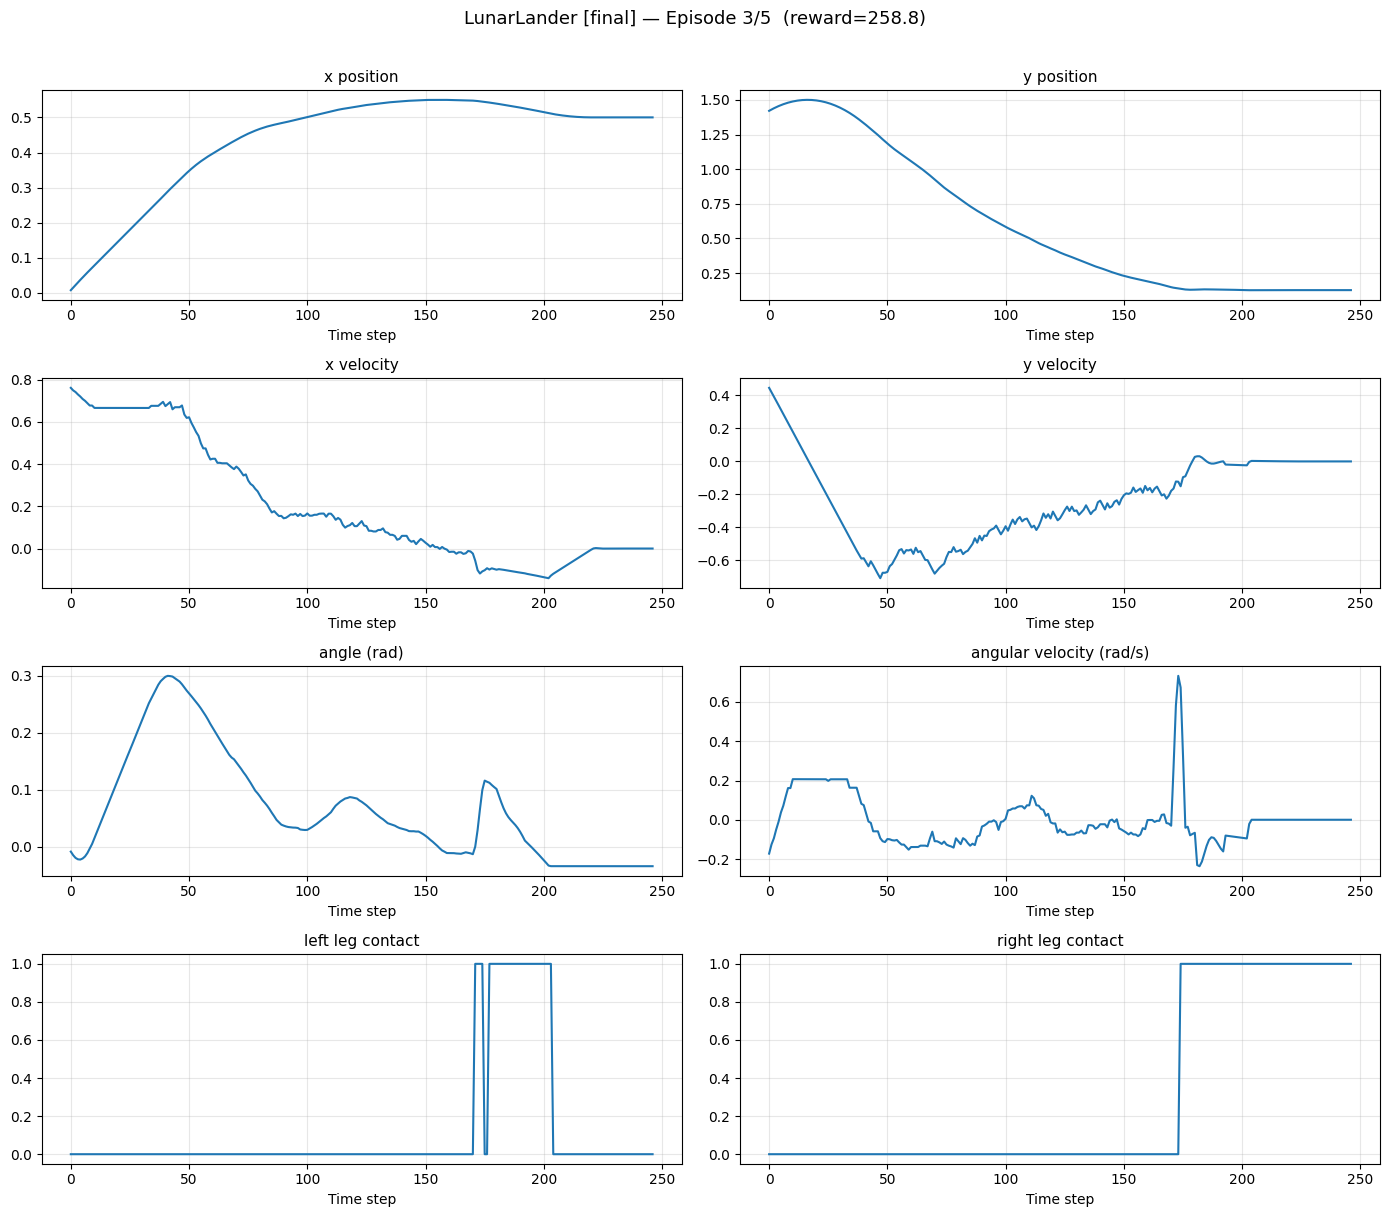

  Plot saved -> lunar_lander_final_ep3.png

Episode  4/5 | reward:    293.2 | steps: 161


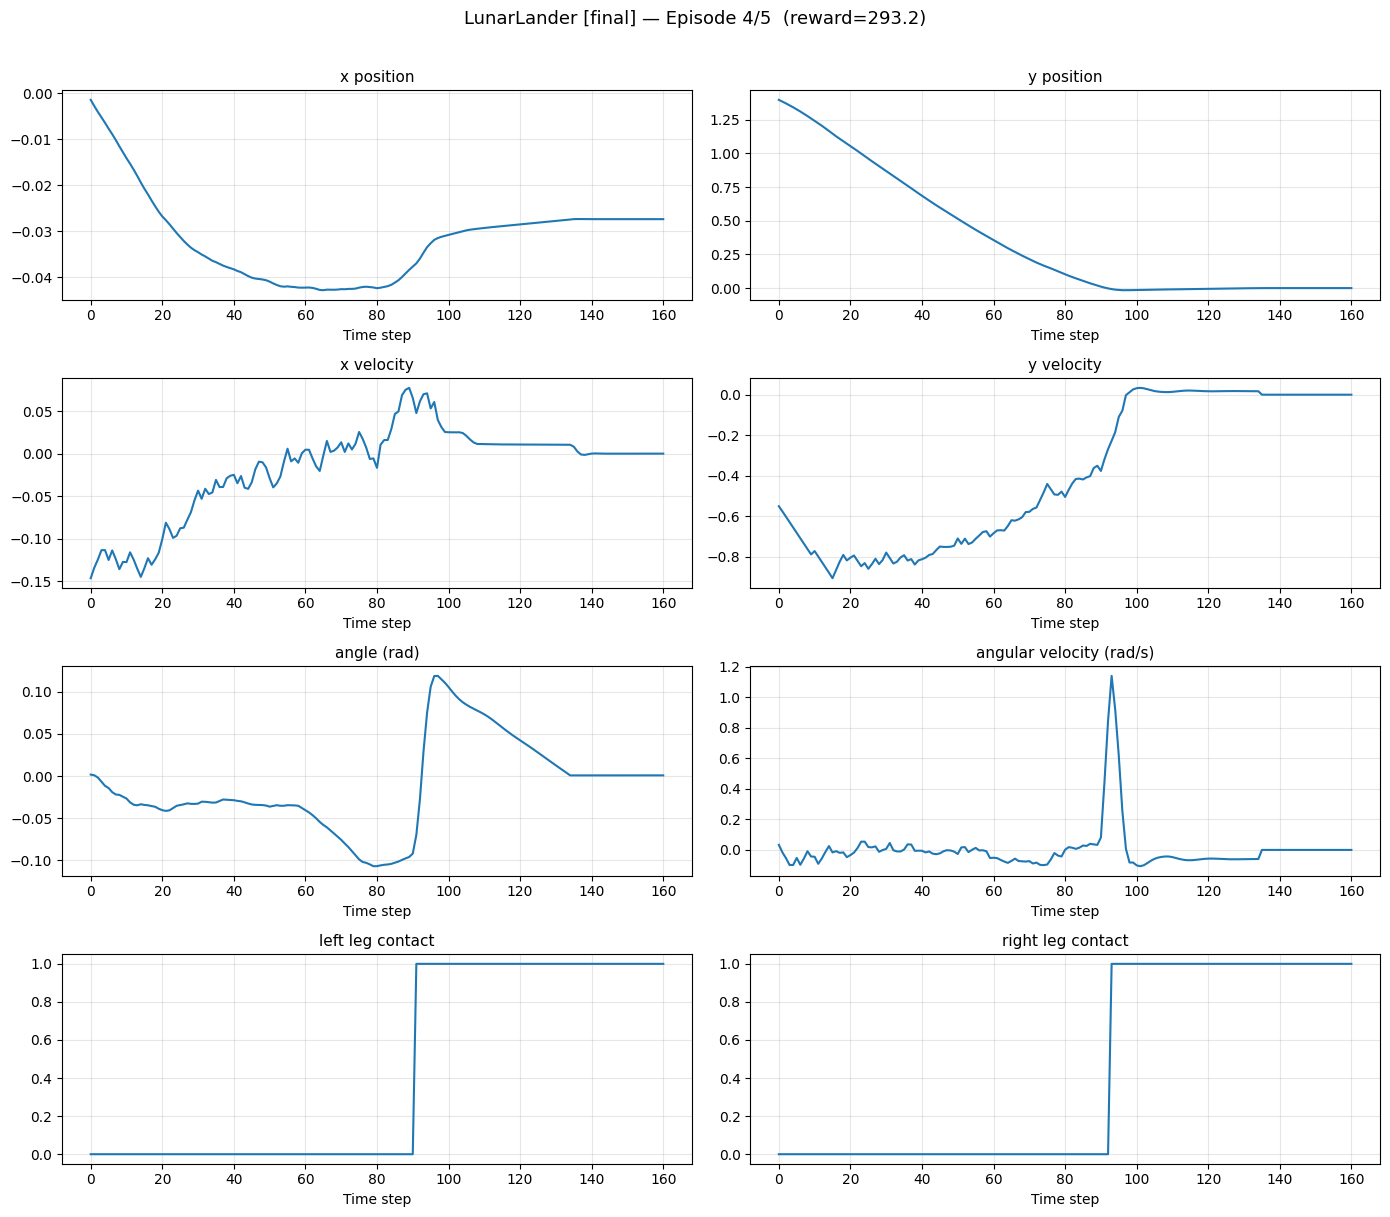

  Plot saved -> lunar_lander_final_ep4.png

Episode  5/5 | reward:    286.3 | steps: 171


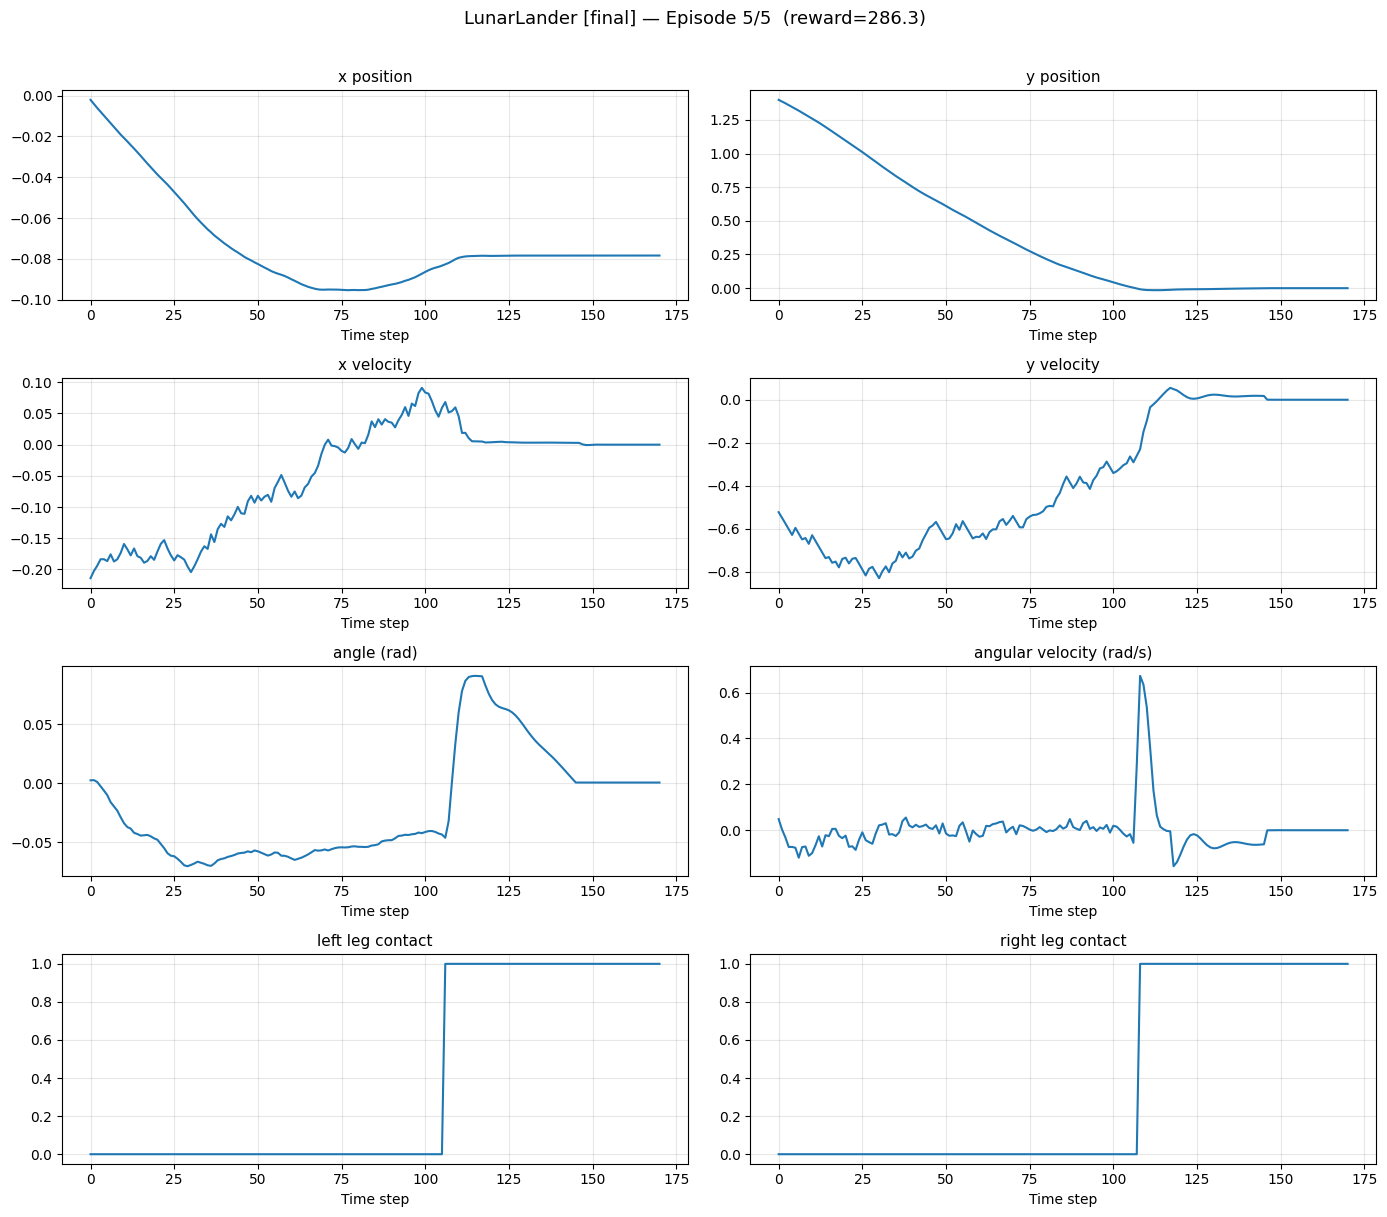

  Plot saved -> lunar_lander_final_ep5.png

Done.


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                      INFERENCE  CELL                            ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt

# ── Config (must match training) ──────────────────────────────────────────────
FINAL_PATH = 'lunar_lander_ac_final.pt'
BEST_PATH  = 'lunar_lander_ac_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Model (must match training) ───────────────────────────────────────────────
class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1   = nn.Linear(8,   256)
        self.fc2   = nn.Linear(256, 256)
        self.fc_pi = nn.Linear(256, 4)
        self.fc_q  = nn.Linear(256, 4)

    def _trunk(self, x):
        return F.relu(self.fc2(F.relu(self.fc1(x))))

    def pi(self, x, softmax_dim=0):
        return F.softmax(self.fc_pi(self._trunk(x)), dim=softmax_dim)

    def q(self, x):
        return self.fc_q(self._trunk(x))

# ── Inference ─────────────────────────────────────────────────────────────────
def run_inference(save_path=FINAL_PATH, n_episodes=5):
    """
    save_path : FINAL_PATH (default) 또는 BEST_PATH
    n_episodes: 렌더링할 에피소드 수
    """
    env = gym.make('LunarLander-v2', render_mode='human')

    model = ActorCritic().to(device)
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()
    model_tag = 'final' if save_path == FINAL_PATH else 'best'
    print(f'[{model_tag}] model loaded from {save_path}')
    print(f'Running {n_episodes} episodes...\n')

    var_labels = [
        'x position',        'y position',
        'x velocity',        'y velocity',
        'angle (rad)',        'angular velocity (rad/s)',
        'left leg contact',  'right leg contact',
    ]

    for ep in range(n_episodes):
        s, _         = env.reset()
        done         = False
        obs_history  = []
        total_reward = 0.0

        with torch.no_grad():
            while not done:
                obs_history.append(s.copy())
                prob = model.pi(torch.from_numpy(s).float().to(device))
                a    = Categorical(prob).sample().item()
                s, r, done, truncated, _ = env.step(a)
                done = done or truncated
                total_reward += r

        steps = len(obs_history)
        print(f'Episode {ep+1:2d}/{n_episodes} | reward: {total_reward:8.1f} | steps: {steps}')

        # ── Plot ──────────────────────────────────────────────────────────────
        obs = np.array(obs_history)   # (T, 8)
        t   = np.arange(steps)

        fig, axes = plt.subplots(4, 2, figsize=(14, 12))
        for ax, col, label in zip(axes.flatten(), range(8), var_labels):
            ax.plot(t, obs[:, col], linewidth=1.5)
            ax.set_title(label, fontsize=11)
            ax.set_xlabel('Time step')
            ax.grid(True, alpha=0.3)

        plt.suptitle(
            f'LunarLander [{model_tag}] — Episode {ep+1}/{n_episodes}  (reward={total_reward:.1f})',
            fontsize=13, y=1.01
        )
        plt.tight_layout()
        plot_path = f'lunar_lander_{model_tag}_ep{ep+1}.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Plot saved -> {plot_path}\n')

    env.close()
    print('Done.')

# ── 실행 ──────────────────────────────────────────────────────────────────────
run_inference(save_path=FINAL_PATH)      # 최종 모델, 5 에피소드
# run_inference(save_path=BEST_PATH)     # best 모델로 추론하려면 이 줄 실행